# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Hernando, Claire Marie M. 
- _Student No._: 2024-12904
- _Section_: THU-TX-1
  
### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report figure
**Problem 1**
![First 5 Eigenfunctions of the Harmonic Oscillator](wavefunctions.png)
*Figure 1 shows the first 5 eigenfunctions, shifted vertically by its eigenvalues, applying the formula $f_n = \psi_n + \mathscr{E}_n$, and a visual scaling factor of $0.5$ to avoid any overlap. The eigenfunctions are overlayed on the harmonic potential $V(x)$.*

**Problem 2**
![Energy Analysis of the Numerical and Theoretical Outputs](comparing_eigenenergies.png)
*Figure 2 (a) and (b) shows the comparison between the numerical and theoretical values of the first 100 eigenenergies and its absolute error analysis.*

![Plot of the Potential and Ground State Probability Density](potential_vs_ground_state_density.png)
*Figure 3 shows the plot of the potential and the probability density of the ground state in a twin-axis plot.* 

### Report discussion

As seen in Figures 2 and 3, we can say that yes, we obtained the expected results for both the eigenenergies and the ground state wave function. 

For the eigenenergies, applying a uniform electric field $E$ introduces a constant linear perturbation $qEx$, which shifts all energy levels downward by a uniform classical polarization offset:$$\mathscr{E}_n = \hbar\omega\left(n+\frac{1}{2}\right) - \frac{q^2 E^2}{2m\omega^2}$$Our numerical eigenvalues match with the theoretical predictions, with only minor absolute errors ($\sim 10^{-4}$) at low $n$ that steadily increase as $n$ increases, due to finite-difference spatial discretization error ($\mathcal{O}(\Delta x^2)$) on a discrete grid.

For the ground state wavefunction, we can see that the parabolic curvature ($m\omega^2$) remains completely unchanged. Consequently, the ground state probability density $|\psi_0(x)|^2$ retains its characteristic symmetric Gaussian shape, shifting its center to the new potential energy minimum at $x_0 = -\frac{qE}{m\omega^2}$.

---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [1]:
# code here

### **a)** The shown matrix was verified using pen and paper solution.

### **b)** Writing the function that outputs the Hamiltonian matrix (H = T + V)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Setting-up the function that outputs the Hamiltonian matrix
def hamiltonian(x_pos, potential_array, mass):
    
    # Defining variables
    N = len(x_pos)
    dx = x_pos[1] - x_pos[0]
    hbar = 1.0 

    # Setting up the matrix of T thru its diagonals
    main_diag = -2 * np.eye(N) 
    off_diag_upper = np.eye(N, k=1)
    off_diag_lower = np.eye(N, k=-1)

    # Setting up the equations for T and V
    T = ((- hbar**2) / (2 * mass * dx**2)) * (main_diag + off_diag_upper + off_diag_lower) 
    V = np.eye(N) * (potential_array) # This is known. 

    return T + V # This outputs the Hamiltonian (H = T + V) 

### **c)** Testing the Hamiltonian in **b** for given $V(x)$

In [3]:
# Testing hamiltonian in V_harmonic (V(x))
# Setting up parameters 
N = 1000 
m = 1.0
omega = 1.0 
x_lim = 3.0 

# Generating grids
x = np.linspace (-x_lim, x_lim, N)    
dx = x[1] - x[0]

# Writing the equation of V_harmonic (V(x))
V_harmonic = 0.5 * m * (omega**2) * (x**2)

# Computing the Hamiltonian and solving the eigenvalue problem
H = hamiltonian(x, V_harmonic, mass=m)
eigenvalues, eigenvectors = np.linalg.eigh(H)

In [4]:
# Obtaining first N = 5 eigenfunctions of the Hamiltonian and their corresponding eigenvalues 
# Setting number of states to check and plot
n = 5

# Know the numerical values of eigenvalues by printing first before plotting
print(f"The first {n} eigenvalues are:")
for i in range(n):
    print(f"E_{i} = {eigenvalues[i]}") 

The first 5 eigenvalues are:
E_0 = 0.5003769833860906
E_1 = 1.5059011509596472
E_2 = 2.5401223229983247
E_3 = 3.6609431975221485
E_4 = 4.946757085059431


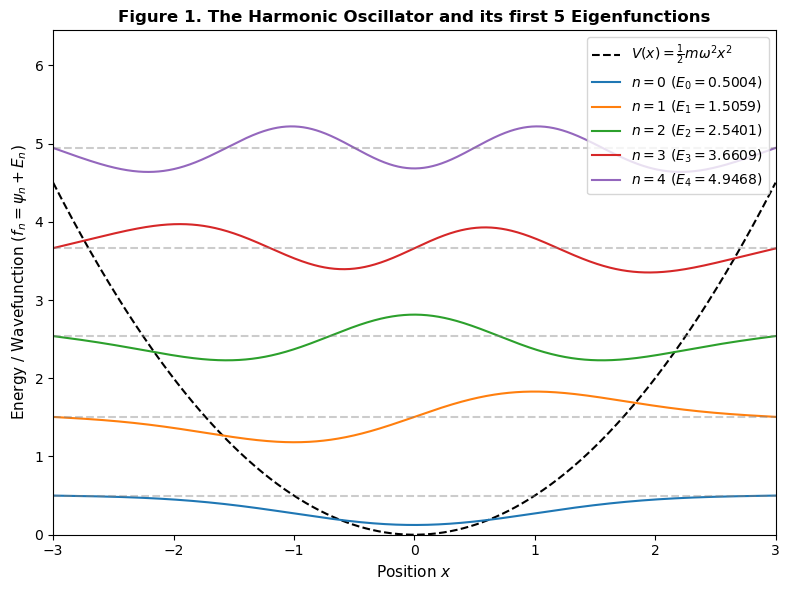

In [5]:
# Plotting the eigenfunctions
fix, ax = plt.subplots(figsize=(8, 6))

# Overlaying the harmonic potential V_harmonic (V(x))
ax.plot(x, V_harmonic, "k--", linewidth=1.5, label=r"$V(x) = \frac{1}{2}m\omega^2 x^2$")

scale_factor = 0.5 # This is to avoid overlapping

# Plotting the wavefunctions following f_n = psi_n + E_n
for i in range(n):
    E_i = eigenvalues[i]
    psi_i = eigenvectors[:, i] / np.sqrt(dx) 

    ax.plot(x, E_i + scale_factor * psi_i, label=f"$n={i}$ ($E_{{{i}}}={E_i:.4f}$)", linewidth=1.5)
    ax.axhline(E_i, color="gray", linestyle="--", alpha=0.4) 

# Formatting whole plot 
ax.set_xlim(-x_lim, x_lim)
ax.set_ylim(0, eigenvalues[n -1] + 1.5) # To fit all 5 states
ax.set_xlabel("Position $x$", fontsize=11)
ax.set_ylabel(r"Energy / Wavefunction ($f_n = \psi_n + E_n$)", fontsize=11)
ax.set_title(f"Figure 1. The Harmonic Oscillator and its first {n} Eigenfunctions", fontsize=12, weight="bold")
ax.legend(loc="upper right")
ax.grid(False)

plt.tight_layout()
plt.savefig("wavefunctions.png", dpi=300)
plt.show()

#### Problem 1 code summary\

This code solves the 1D Time-Independent Schrodinger Equation for a quantum harmonic oscillator by constructing a discretized Hamiltonian matrix thru central finite difference approximations, with $x$ limited to [-3, 3], causing physical limitations on the 4th and 5th wavefunctions. Using np.linalg.eigh, this numerically computes the eigenvalues and eigenvectors across a 1000-point 1D grid. This then plots the first 5 eigenfunctions, shifted vertically by its eigenvalues, applying the formula $f_n = \psi_n + \mathscr{E}_n$, and a visual scaling factor of $0.5$ to avoid any overlap.   

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

In [6]:
# code here

## Setting up the matrix
I used the code for my Hamiltonian matrix in Problem 1 since they are just the same set-up and concept. I just need to change the parameters and the $V(x)$ to solve Problem 2.

## Setting up the parameters
The parameters are designed to cater to the 100 eigenenergies needed to be solved.

In [7]:
# Setting up parameters
m = 1.0
hbar = 1.0
omega = 1.0
qE = 1.0 

# Generating grids
N = 1500 
x_lim = 15.0 # Should be enough to contain high-n states without boundary effects  
x = np.linspace (-x_lim, x_lim, N)    
dx = x[1] - x[0]

# Writing the equation of effective potential V_eff (V(x))
V_eff = (0.5 * m * (omega**2) * (x**2)) + (qE * x)

# Computing the Hamiltonian and solving the eigenvalue problem
H = hamiltonian(x, V_eff, mass=m)
eigenvalues, eigenvectors = np.linalg.eigh(H)

## **a)** Solving the 100 eigenenergies and plotting them to compare with the theoretical value

In [8]:
# Setting number of states to check and plot
n = 100

# Setting up the array for E_theoretical
n_indices = np.arange(n)

# Getting 100 eigenenergies of the resulting Hamiltonian (E_numerical)
E_numerical = eigenvalues[:n] # This gives us the numerical values 

# Setting up equation for theoretical value (E_theoretical)
E_theoretical = (hbar * omega * (n_indices + 0.5)) - ((qE**2) / (2 * m * (omega**2)))

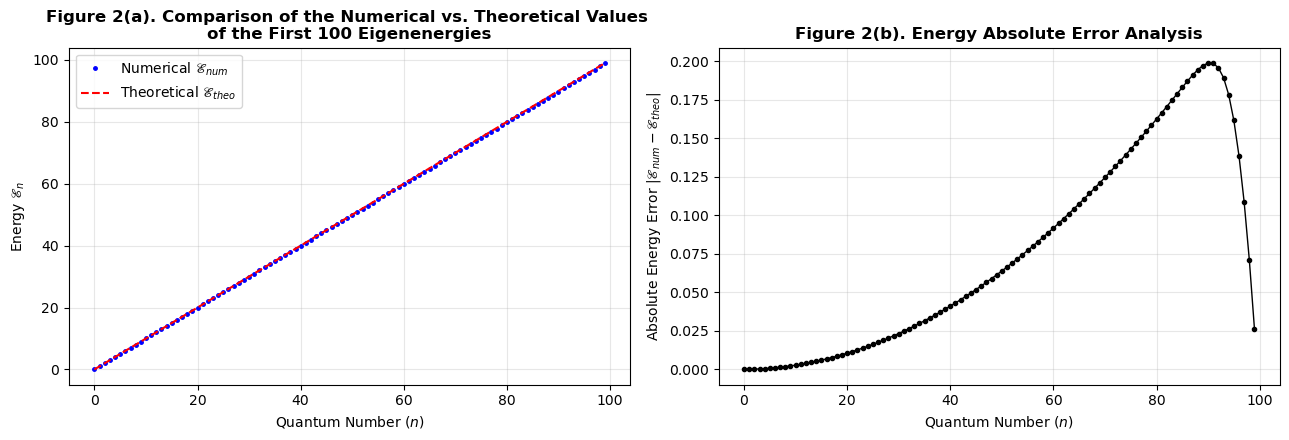

In [9]:
# Plotting eigenenergies for both numerical and theoretical computations 
fig1, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot of Numerical vs. Theoretical Energies
ax[0].plot(n_indices, E_numerical, 'b.', label='Numerical $\\mathscr{E}_{num}$', markersize=5) # This is for numerical
ax[0].plot(n_indices, E_theoretical, 'r--', label='Theoretical $\\mathscr{E}_{theo}$', lw=1.5) # This is for theoretical

ax[0].set_xlabel('Quantum Number $(n)$')
ax[0].set_ylabel('Energy $\\mathscr{E}_n$')
ax[0].set_title(f'Figure 2(a). Comparison of the Numerical vs. Theoretical Values \nof the First {n} Eigenenergies', fontsize=12, weight="bold")
ax[0].legend(loc="upper left")
ax[0].grid(True, alpha=0.3)

# To know if we get the expected result, we need the error plot
# Plotting Absolute Energy Error
ax[1].plot(n_indices, np.abs(E_numerical - E_theoretical), 'k.-', lw=1)
ax[1].set_xlabel('Quantum Number $(n)$')
ax[1].set_ylabel('Absolute Energy Error $|\\mathscr{E}_{num} - \\mathscr{E}_{theo}|$')
ax[1].set_title('Figure 2(b). Energy Absolute Error Analysis', fontsize=12, weight="bold")
ax[1].grid(True, alpha=0.3) 

plt.tight_layout()

fig1.savefig("comparing_eigenenergies.png", dpi=300, bbox_inches="tight")

plt.show()

From the figures above, we can say that we got the expected result since in Figure 2(a), the theoretical and numerical values are nearly similar with each other, while if we look at Figure 2(b) showing the absolute error analysis, if the quantum number $(n)$ is low, there is near-zero error ($\sim 10^{-4}$), showing that the numerical values match with the theoretical, but as $n$ goes higher, the error also increases steadily. This is because higher energy states posses shorter quantum wavelengths, increasing the finite-difference spatial discretization error on a fixed grid, and they also extend further spatially and begin to experience artificial boundary constraints beyond the limits we initially set.

## **b)** Plotting the potential and the probability density of the ground state

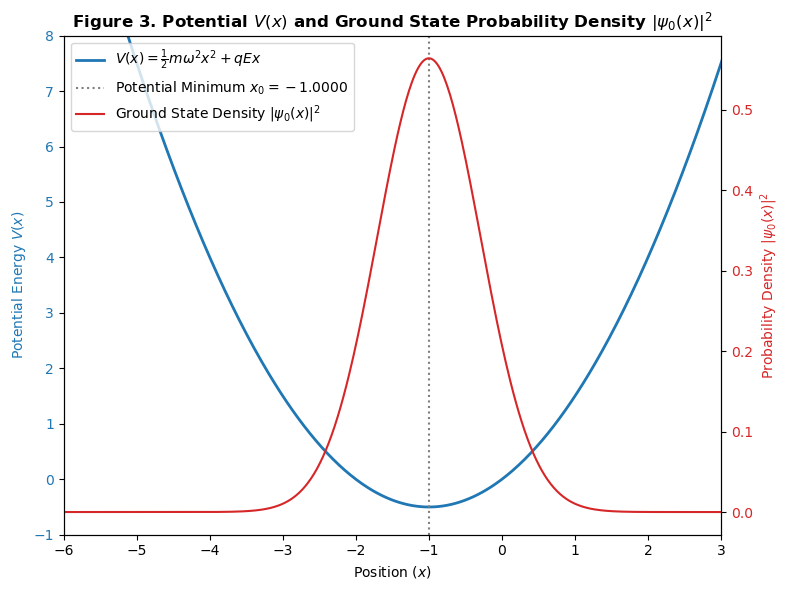

In [10]:
# Normalizing ground state
psi_0 = eigenvectors[:, 0]
prob_density_0 = np.abs(psi_0) ** 2 / dx

# Theoretical minimum location 
x_0 = -qE / (m * (omega**2)) # Shifts the equilibrium minimum away from x=0

# Plotting potential and probability density of the ground state
fig2, ax1 = plt.subplots(figsize=(8, 6)) 

# Plotting Potential of Ground State 
color_v = 'tab:blue'
ax1.set_xlabel('Position $(x)$')
ax1.set_ylabel('Potential Energy $V(x)$', color=color_v)
ax1.plot(x, V_eff, color=color_v, label='$V(x) = \\frac{1}{2}m\\omega^2x^2 + qEx$', lw=2)
ax1.tick_params(axis='y', labelcolor=color_v)
ax1.set_xlim(-6, 3)
ax1.set_ylim(-1,8)
ax1.axvline(x_0, color='gray', linestyle=':', label=f'Potential Minimum $x_0 = {x_0:.4f}$')

# Plotting Probability Density of Ground State, plotting at twin axis
ax2 = ax1.twinx() 
color_p = 'tab:red'
ax2.set_ylabel('Probability Density $|\\psi_0(x)|^2$', color=color_p)
ax2.plot(x, prob_density_0, color=color_p, label=r'Ground State Density $|\psi_0(x)|^2$')
ax2.tick_params(axis='y', labelcolor=color_p)

# Finalizing legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Figure 3. Potential $V(x)$ and Ground State Probability Density $|\psi_0(x)|^2$', fontsize=12, weight="bold")
plt.tight_layout()
fig2.savefig('potential_vs_ground_state_density.png', dpi=300, bbox_inches='tight')
plt.show()


As shown in Figure 3, we can say that the plot makes sense and aligns with the physical expectations of our answer. Here, the ground state probability density aligns directly with our $x_0$, indicated by the vertical line. This shows that the probability density of the ground state concentrates around the classical potential energy minimum, which is exactly what quantum mechanics tells us. The parabolic curve depicted by $V(x)$ has also been unchanged, showing a symmetric Gaussian. Lastly, the probability density decays smoothly into the potential walls, instead of dropping abruptly to zero, demonstrating quantum tunneling into forbidden regions. 

#### Problem 2 code summary
This script solves the 1D Time-Independent Schrodinger Equation for a quantum harmonic oscillator perturbed by a uniform electric field using central finite difference approximations. By creating a discrete Hamiltonian matrix and applying np.linalg.eigh, we get the eigenenergies and the ground state wavefunction, and compare them against the theoretical value given by $\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}$. We then applied an absolute error analysis to further understand the behavior of the plots as the quantum numbers $(n)$ increases, as well as a twin-axis plot to visually verify that the ground state density remains a symmetric Gaussian centered at the shifted potential equilibrium marked by $(x_0)$.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)